# Phase 1: Real-World Dataset Understanding & Exploratory Data Analysis
## Statlog (German Credit Data) — 1,000-Record Credit Risk Benchmark
### Credit Risk & Loan Decision Intelligence Platform

---

## SECTION 1 — Dataset Introduction & Business Context

In credit risk modeling, developing reliable machine learning algorithms requires validating architectural decisions on real-world empirical data. While synthetic datasets (such as our 50-record educational dataset) enable rapid structural prototyping and application workflow testing, a **real-world historical credit-risk benchmark dataset** is essential for evaluating statistical distributions, feature associations, and model performance.

In this notebook, we perform an exhaustive, 20-section Exploratory Data Analysis (EDA) on the canonical **UCI Statlog (German Credit Data)** dataset.

---
## SECTION 2 — Source and Dataset Provenance

### Dataset Provenance:
- **Repository**: UCI Machine Learning Repository
- **Dataset**: Statlog (German Credit Data)
- **Official Source URL**: `https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data`
- **Donor / Creator**: Professor Dr. Hans Hofmann, Institut für Statistik und Ökonometrie, Universität Hamburg (1994).
- **Domain Context**: Historical European banking records of consumer and personal loans denominated in Deutsche Mark (DM).
- **Important Disclaimer**: This is a historical credit-risk benchmark dataset. It is **NOT** Indian lending data, production banking data, or representative of Indian borrowers.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configure plotting and pandas formatting
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print(f"Numpy version   : {np.__version__}")
print(f"Pandas version  : {pd.__version__}")
print(f"Matplotlib vers : {plt.matplotlib.__version__}")
print(f"Seaborn version : {sns.__version__}")

Numpy version   : 2.4.6
Pandas version  : 3.0.3
Matplotlib vers : 3.11.1
Seaborn version : 0.13.2


---
## SECTION 3 — Load Dataset Dynamically

We load the canonical raw dataset from `data/raw/german_credit_1000.csv`.

In [3]:
data_path = '../data/raw/german_credit_1000.csv' if os.path.exists('../data/raw/german_credit_1000.csv') else 'data/raw/german_credit_1000.csv'
df = pd.read_csv(data_path)
print("Dataset loaded successfully!")
df.head(5)

Dataset loaded successfully!


,status_existing_checking_account,duration_in_months,credit_history,purpose,credit_amount,savings_account_bonds,present_employment_since,installment_rate_pct_disposable_income,personal_status_sex,other_debtors_guarantors,present_residence_since,property,age_years,other_installment_plans,housing,existing_credits_count,job,people_liable_maintenance,telephone,foreign_worker,default
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201,1


---
## SECTION 4 — Dataset Shape

We dynamically inspect the dimensions of the loaded dataset.

In [4]:
n_rows, n_cols = df.shape
print(f"Dataset Shape:")
print(f"  • Total Rows (Observations) : {n_rows}")
print(f"  • Total Columns (Features)  : {n_cols}")

Dataset Shape:
  • Total Rows (Observations) : 1000
  • Total Columns (Features)  : 21


---
## SECTION 5 — Column Names & Schema Inventory

We dynamically inspect all column names present in the dataset.

In [5]:
print("Dataset Columns:")
for idx, col in enumerate(df.columns, 1):
    print(f"  {idx:02d}. {col}")

Dataset Columns:
  01. status_existing_checking_account
  02. duration_in_months
  03. credit_history
  04. purpose
  05. credit_amount
  06. savings_account_bonds
  07. present_employment_since
  08. installment_rate_pct_disposable_income
  09. personal_status_sex
  10. other_debtors_guarantors
  11. present_residence_since
  12. property
  13. age_years
  14. other_installment_plans
  15. housing
  16. existing_credits_count
  17. job
  18. people_liable_maintenance
  19. telephone
  20. foreign_worker
  21. default


---
## SECTION 6 — Data Types Analysis

We dynamically analyze feature data types, separating numerical features from categorical features.

In [6]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop('default', errors='ignore').tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Data Types Summary:")
print(f"  • Numerical Features   ({len(num_cols)}): {num_cols}")
print(f"  • Categorical Features ({len(cat_cols)}): {cat_cols}")
print(f"  • Target Column        : 'default'")
print("-" * 60)
print(df.dtypes)

Data Types Summary:
  • Numerical Features   (7): ['duration_in_months', 'credit_amount', 'installment_rate_pct_disposable_income', 'present_residence_since', 'age_years', 'existing_credits_count', 'people_liable_maintenance']
  • Categorical Features (13): ['status_existing_checking_account', 'credit_history', 'purpose', 'savings_account_bonds', 'present_employment_since', 'personal_status_sex', 'other_debtors_guarantors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']
  • Target Column        : 'default'
------------------------------------------------------------
status_existing_checking_account            str
duration_in_months                        int64
credit_history                              str
purpose                                     str
credit_amount                             int64
savings_account_bonds                       str
present_employment_since                    str
installment_rate_pct_disposable_income    int64
pe

---
## SECTION 7 — Missing-Value Analysis

We dynamically evaluate the presence of null, NaN, or missing values across all columns.

In [7]:
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_counts, 'Missing Pct (%)': missing_pct})
print("Missing Values per Column:")
print(missing_df)
total_missing = missing_counts.sum()
print(f"\nTotal Missing Values in Dataset: {total_missing}")

Missing Values per Column:
                                        Missing Count  Missing Pct (%)
status_existing_checking_account                    0              0.0
duration_in_months                                  0              0.0
credit_history                                      0              0.0
purpose                                             0              0.0
credit_amount                                       0              0.0
savings_account_bonds                               0              0.0
present_employment_since                            0              0.0
installment_rate_pct_disposable_income              0              0.0
personal_status_sex                                 0              0.0
other_debtors_guarantors                            0              0.0
present_residence_since                             0              0.0
property                                            0              0.0
age_years                                         

---
## SECTION 8 — Duplicate Analysis

We dynamically check for identical duplicate rows across the entire dataset.

In [8]:
duplicate_count = df.duplicated().sum()
print(f"Total Duplicate Rows: {duplicate_count}")

Total Duplicate Rows: 0


---
## SECTION 9 — Target Identification & Credit Risk Definition

In the original UCI Statlog dataset documentation (`german.doc`):
- `1` = Good (Creditworthy / Non-default)
- `2` = Bad (Default / Uncreditworthy)

In standard credit risk machine learning modeling, binary classification models predict the probability of the adverse event (**default**):
- **`0` = Non-default / Good Credit Risk** (Obligations repaid duly)
- **`1` = Default / Bad Credit Risk** (Failure to service debt obligations)

The raw CSV preserves this canonical 0/1 mapping.

In [9]:
target_series = df['default']
print("Target Variable Summary:")
print(f"  • Column Name : {target_series.name}")
print(f"  • Data Type   : {target_series.dtype}")
print(f"  • Unique Vals : {target_series.unique().tolist()}")

Target Variable Summary:
  • Column Name : default
  • Data Type   : int64
  • Unique Vals : [0, 1]


---
## SECTION 10 — Target Distribution & Class Imbalance

We dynamically compute the class frequencies and proportions for the target variable.

Target Class Distribution:
                 Class  Count  Percentage (%)
0 (Non-default / Good)    700            70.0
     1 (Default / Bad)    300            30.0


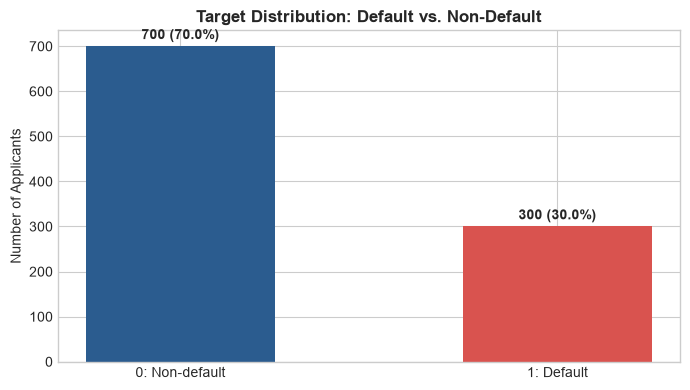

In [10]:
target_counts = df['default'].value_counts().sort_index()
target_props = df['default'].value_counts(normalize=True).sort_index() * 100

target_dist_df = pd.DataFrame({
    'Class': ['0 (Non-default / Good)', '1 (Default / Bad)'],
    'Count': target_counts.values,
    'Percentage (%)': target_props.values
})
print("Target Class Distribution:")
print(target_dist_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['0: Non-default', '1: Default'], target_counts.values, color=['#2b5c8f', '#d9534f'], width=0.5)
ax.set_title('Target Distribution: Default vs. Non-Default', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Applicants')
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height} ({height/len(df)*100:.1f}%)',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

---
## SECTION 11 — Numerical Descriptive Statistics

We dynamically compute key summary statistics for all numerical features: mean, standard deviation, median, IQR, minimum, maximum, and skewness.

In [11]:
num_summary = df[num_cols].describe().T
num_summary['median'] = df[num_cols].median()
num_summary['IQR'] = num_summary['75%'] - num_summary['25%']
num_summary['skewness'] = df[num_cols].skew()

print("Numerical Descriptive Statistics:")
display(num_summary[['count', 'mean', 'std', 'min', '25%', 'median', '75%', 'max', 'IQR', 'skewness']])

Numerical Descriptive Statistics:


,count,mean,std,min,25%,median,75%,max,IQR,skewness
duration_in_months,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0,12.00,1.094184
credit_amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0,2606.75,1.949628
installment_rate_pct_disposable_income,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0,2.00,-0.531348
present_residence_since,1000.0,2.845,1.103718,1.0,2.0,3.0,4.00,4.0,2.00,-0.272570
age_years,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0,15.00,1.020739
existing_credits_count,1000.0,1.407,0.577654,1.0,1.0,1.0,2.00,4.0,1.00,1.272576
people_liable_maintenance,1000.0,1.155,0.362086,1.0,1.0,1.0,1.00,2.0,0.00,1.909445


---
## SECTION 12 — Categorical Feature Distributions

We dynamically inspect the frequency distribution and unique cardinality of each categorical feature.

In [12]:
print(f"Categorical Features Inventory ({len(cat_cols)} columns):\n")
for col in cat_cols:
    vc = df[col].value_counts()
    print(f"Feature: '{col}' (Cardinality: {len(vc)})")
    for val, cnt in vc.items():
        print(f"    - {val:6s}: {cnt:4d} ({cnt/len(df)*100:5.1f}%)")
    print("-" * 50)

Categorical Features Inventory (13 columns):

Feature: 'status_existing_checking_account' (Cardinality: 4)
    - A14   :  394 ( 39.4%)
    - A11   :  274 ( 27.4%)
    - A12   :  269 ( 26.9%)
    - A13   :   63 (  6.3%)
--------------------------------------------------
Feature: 'credit_history' (Cardinality: 5)
    - A32   :  530 ( 53.0%)
    - A34   :  293 ( 29.3%)
    - A33   :   88 (  8.8%)
    - A31   :   49 (  4.9%)
    - A30   :   40 (  4.0%)
--------------------------------------------------
Feature: 'purpose' (Cardinality: 10)
    - A43   :  280 ( 28.0%)
    - A40   :  234 ( 23.4%)
    - A42   :  181 ( 18.1%)
    - A41   :  103 ( 10.3%)
    - A49   :   97 (  9.7%)
    - A46   :   50 (  5.0%)
    - A45   :   22 (  2.2%)
    - A44   :   12 (  1.2%)
    - A410  :   12 (  1.2%)
    - A48   :    9 (  0.9%)
--------------------------------------------------
Feature: 'savings_account_bonds' (Cardinality: 5)
    - A61   :  603 ( 60.3%)
    - A65   :  183 ( 18.3%)
    - A62   :  103 ( 1

---
## SECTION 13 — Numerical Feature Distributions (Histograms & KDEs)

We visualize the empirical probability densities and histograms for key numerical features.

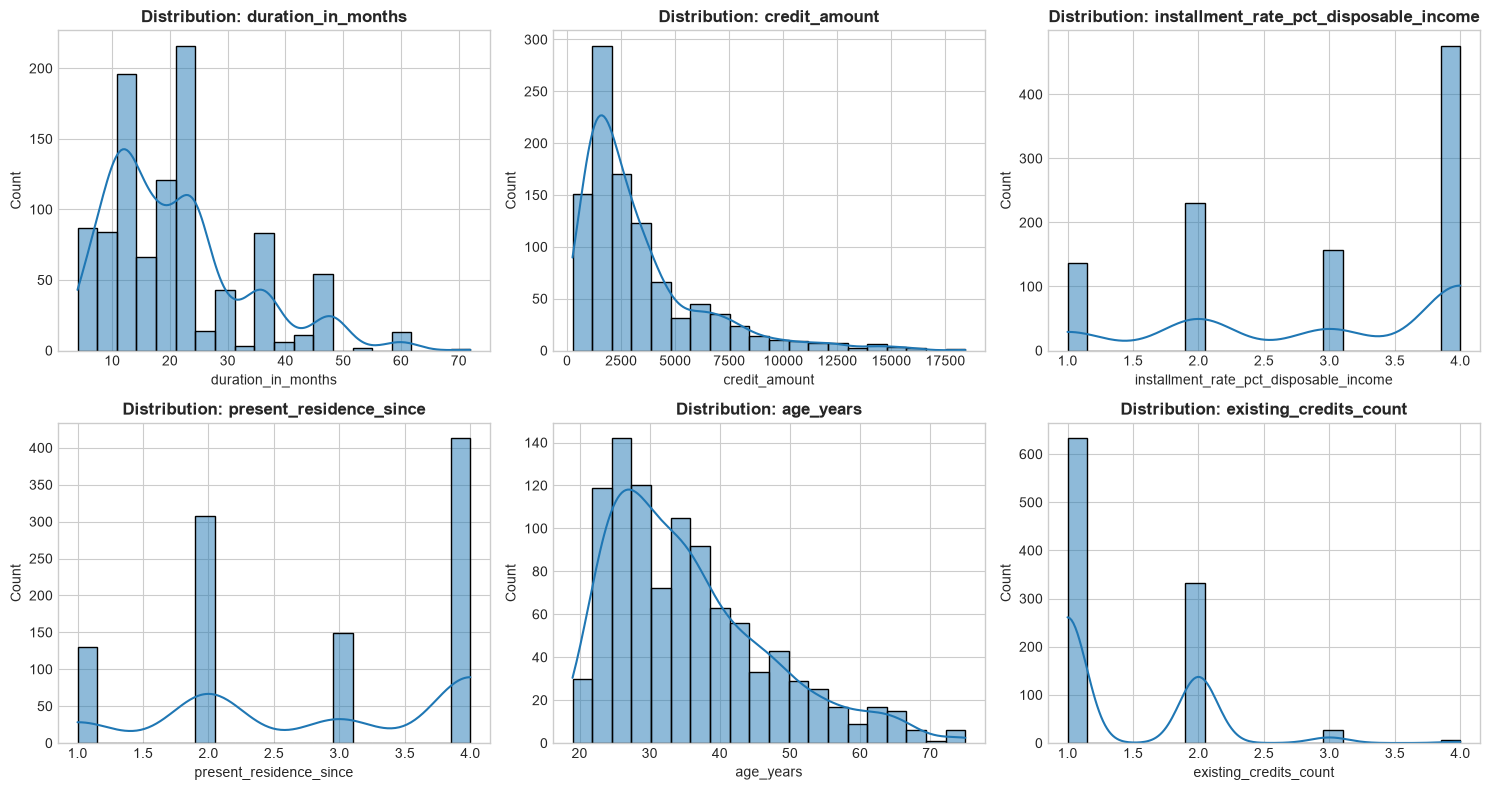

In [13]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
axes = axes.flatten()

plot_num_features = ['duration_in_months', 'credit_amount', 'installment_rate_pct_disposable_income', 
                     'present_residence_since', 'age_years', 'existing_credits_count']

for i, col in enumerate(plot_num_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='#1f77b4', bins=20)
    axes[i].set_title(f'Distribution: {col}', fontweight='bold')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

---
## SECTION 14 — Outlier Inspection (IQR Method & Boxplots)

We inspect numerical features for potential statistical outliers using the standard Interquartile Range (IQR) rule ($Q_1 - 1.5 \times \text{IQR}$, $Q_3 + 1.5 \times \text{IQR}$).

Outlier count for 'duration_in_months' (bounds: [-6.0, 42.0]): 70 rows (7.0%)
Outlier count for 'credit_amount' (bounds: [-2544.6, 7882.4]): 72 rows (7.2%)
Outlier count for 'age_years' (bounds: [4.5, 64.5]): 23 rows (2.3%)


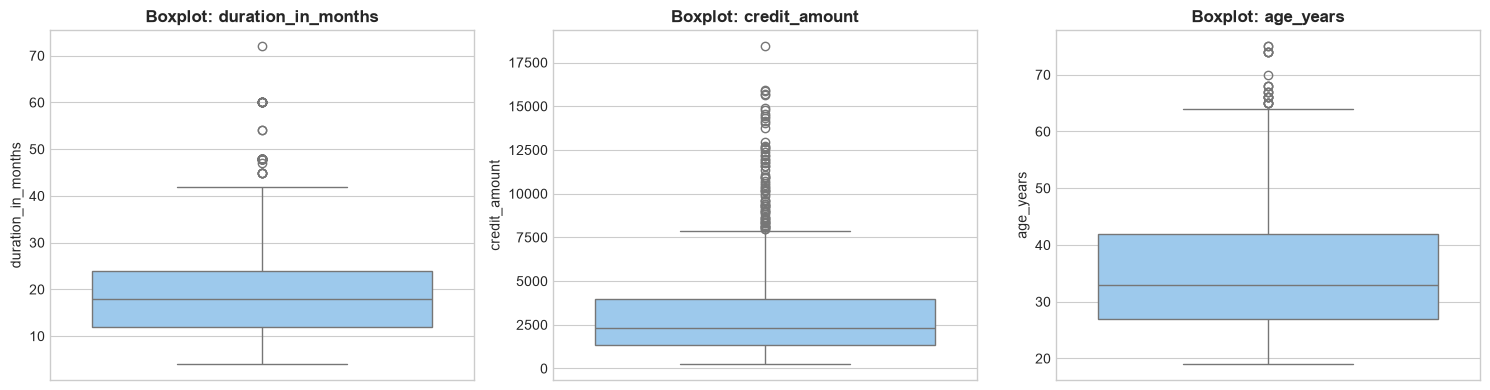

In [14]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))
outlier_cols = ['duration_in_months', 'credit_amount', 'age_years']

for i, col in enumerate(outlier_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='#90caf9')
    axes[i].set_title(f'Boxplot: {col}', fontweight='bold')
    
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Outlier count for '{col}' (bounds: [{lower_bound:.1f}, {upper_bound:.1f}]): {len(outliers)} rows ({len(outliers)/len(df)*100:.1f}%)")

plt.tight_layout()
plt.show()

---
## SECTION 15 — Feature-vs-Target Analysis

We examine the empirical default rate across different categorical attributes and compare numerical distributions across target classes.

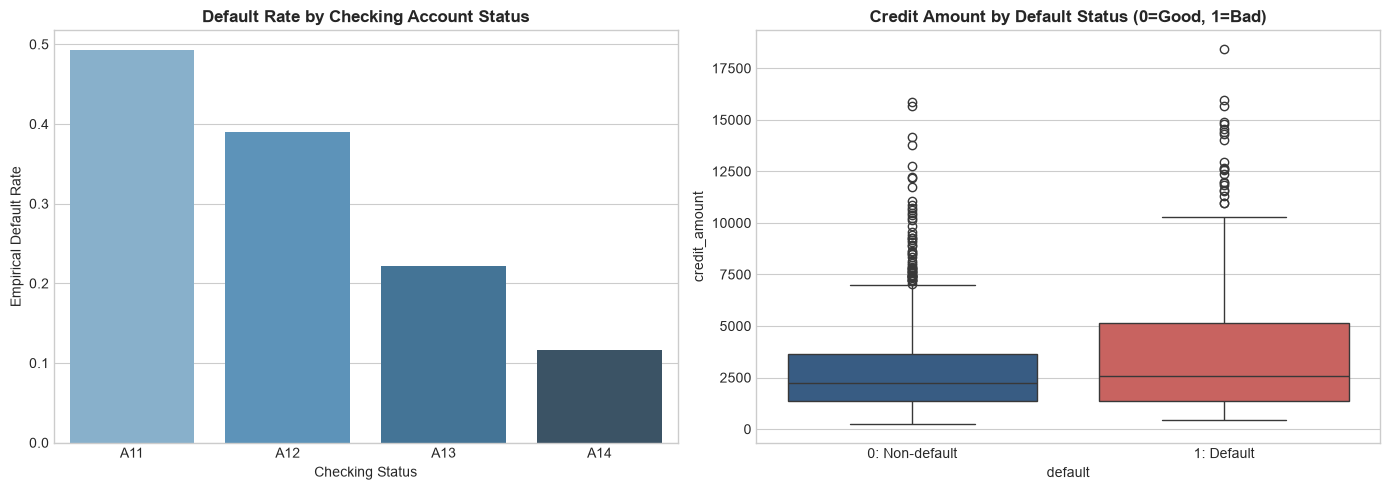

In [15]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# Default rate by checking account status
chk_summary = df.groupby('status_existing_checking_account')['default'].agg(['count', 'mean']).reset_index()
chk_summary.columns = ['Checking Status', 'Count', 'Default Rate']
sns.barplot(data=chk_summary, x='Checking Status', y='Default Rate', ax=axes[0], palette='Blues_d')
axes[0].set_title('Default Rate by Checking Account Status', fontweight='bold')
axes[0].set_ylabel('Empirical Default Rate')

# Credit Amount vs Default
sns.boxplot(data=df, x='default', y='credit_amount', ax=axes[1], palette=['#2b5c8f', '#d9534f'])
axes[1].set_title('Credit Amount by Default Status (0=Good, 1=Bad)', fontweight='bold')
axes[1].set_xticklabels(['0: Non-default', '1: Default'])

plt.tight_layout()
plt.show()

---
## SECTION 16 — Correlation Analysis

We calculate the Pearson correlation matrix among all numerical features.

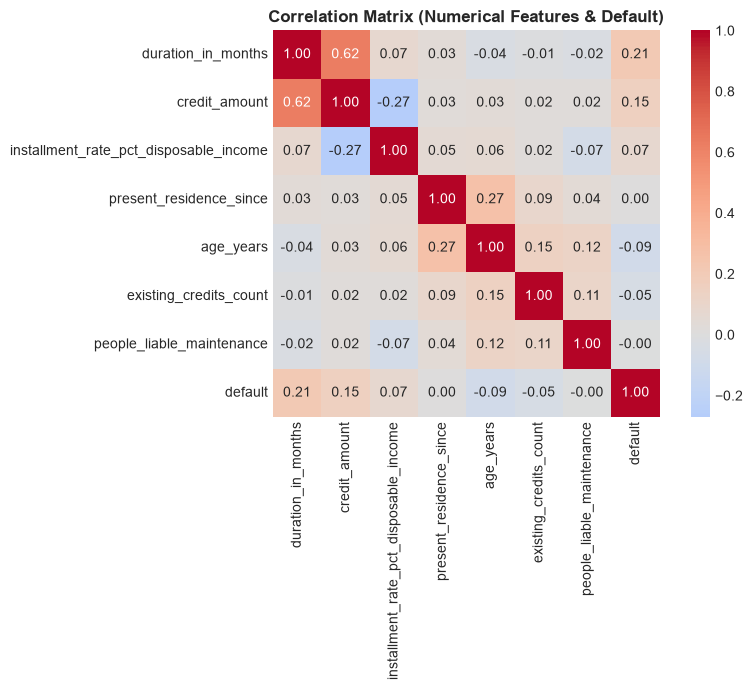

In [16]:
corr_matrix = df[num_cols + ['default']].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, cbar=True, square=True)
plt.title('Correlation Matrix (Numerical Features & Default)', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

---
## SECTION 17 — Data Leakage Review

A rigorous data leakage audit requires inspecting whether any feature contains information generated *after* the loan underwriting decision or performance observation:

| Feature | Observable at Application Time | Leakage Assessment | Official Timing Documentation Notes |
|---|---|---|---|
| `status_existing_checking_account` | Yes | Valid | Pre-existing bank account balance at application time. |
| `duration_in_months` | Yes | Valid | Requested tenure specified in application. |
| `credit_history` | Yes | Valid | Bureau track record prior to application. |
| `purpose` | Yes | Valid | Declared loan purpose on application form. |
| `credit_amount` | Yes | Valid | Requested principal credit amount. |
| `savings_account_bonds` | Yes | Valid | Existing savings balance declared/verified at application. |
| `present_employment_since` | Yes | Valid | Historical employment tenure. |
| `installment_rate_pct_disposable_income` | Yes | Valid | Contractual installment ratio computed from requested terms. |
| `personal_status_sex` | Yes | Valid | Applicant demographic information. |
| `other_debtors_guarantors` | Yes | Valid | Co-signers/guarantors pledged at application. |
| `present_residence_since` | Yes | Valid | Residential tenure at application date. |
| `property` | Yes | Valid | Declared collateral/property assets. |
| `age_years` | Yes | Valid | Applicant age at application date. |
| `other_installment_plans` | Yes | Valid | Existing external credit commitments at other institutions. |
| `housing` | Yes | Valid | Current housing arrangement. |
| `existing_credits_count` | Yes | Valid | Active loans at this institution prior to new loan. |
| `job` | Yes | Valid | Current employment category. |
| `people_liable_maintenance` | Yes | Valid | Number of dependents at application time. |
| `telephone` | Yes | Valid | Customer contact registry status. |
| `foreign_worker` | Yes | Valid | Resident/non-resident labor status. |

> **Timing Uncertainty Note**: In historical datasets like Statlog German Credit, exact operational collection logs are not preserved in documentation. While all 20 features are conventionally structured as pre-decision attributes, potential observational ambiguity (such as checking account balance timing) is documented as an inherent historical data limitation rather than asserted without qualification.

---
## SECTION 18 — Feature Availability Review

Every feature in the 20-variable feature set corresponds to information typically gathered during loan application intake or pre-decision underwriting review. None of the features represent post-disbursal repayment behavior (e.g. days past due during tenure, debt collection actions, or write-off timestamps), which confirms that all 20 attributes can be evaluated legitimately for predictive default scoring.

---
## SECTION 19 — Dataset Limitations

1. **Historical European Macroeconomic Context**: The dataset was recorded in Germany in 1994, with financial figures denominated in Deutsche Mark (DM). It cannot be used as an empirical proxy for modern Indian retail credit dynamics.
2. **Demographic & Fair Lending Considerations**: Attributes such as `personal_status_sex` and `foreign_worker` reflect 1990s data collection practices. In contemporary lending environments (such as Indian RBI guidelines or US ECOA), such attributes are subject to strict regulatory discrimination and bias prevention policies.
3. **Class Imbalance**: The dataset exhibits a 70% Non-default / 30% Default distribution. Evaluation metrics must emphasize discrimination (ROC-AUC, Precision, Recall, F1) over raw classification accuracy.

---
## SECTION 20 — EDA Conclusion & Key Findings

1. **Clean Data Foundation**: The dataset contains 1,000 observations with zero missing values and zero duplicate records.
2. **Feature Diversity**: The dataset encompasses both financial capability indicators (`credit_amount`, `installment_rate_pct_disposable_income`, `savings_account_bonds`) and behavioral stability indicators (`credit_history`, `present_employment_since`, `present_residence_since`).
3. **Target Balance**: The observed target distribution exhibits a 70/30 class proportion, offering a substantial sample of defaults (300 cases) to support statistical cross-validation.

---
## SECTION 21 — Automated Integrity & Validation Suite

We execute 10 programmatic validation assertions to guarantee dataset integrity.

In [17]:
# Programmatic Validation Gate Suite
print("Running Phase 1 Automated Validation Gates...")

# Gate 1: Total records count
assert len(df) == 1000, f"Expected 1000 records, found {len(df)}"
print("  ✓ Gate 1: Record count == 1,000 passed.")

# Gate 2: Column count
assert df.shape[1] == 21, f"Expected 21 columns, found {df.shape[1]}"
print("  ✓ Gate 2: Column count == 21 passed.")

# Gate 3: Zero missing values
assert df.isnull().sum().sum() == 0, "Dataset contains unexpected missing values!"
print("  ✓ Gate 3: Zero missing values confirmed.")

# Gate 4: Zero duplicate rows
assert df.duplicated().sum() == 0, "Dataset contains unexpected duplicate rows!"
print("  ✓ Gate 4: Zero duplicate rows confirmed.")

# Gate 5: Target column present
assert 'default' in df.columns, "'default' column missing from dataframe!"
print("  ✓ Gate 5: Target column 'default' presence confirmed.")

# Gate 6: Target values strictly binary {0, 1}
assert set(df['default'].unique()) == {0, 1}, "Target variable values are not strictly {0, 1}!"
print("  ✓ Gate 6: Binary target values {0, 1} confirmed.")

# Gate 7: Numerical features detected dynamically
assert len(num_cols) > 0, "No numerical features detected!"
print(f"  ✓ Gate 7: {len(num_cols)} numerical features detected.")

# Gate 8: Categorical features detected dynamically
assert len(cat_cols) > 0, "No categorical features detected!"
print(f"  ✓ Gate 8: {len(cat_cols)} categorical features detected.")

# Gate 9: Duration in months is positive
assert (df['duration_in_months'] > 0).all(), "Invalid negative/zero duration values found!"
print("  ✓ Gate 9: Positive loan duration values confirmed.")

# Gate 10: Credit amount is positive
assert (df['credit_amount'] > 0).all(), "Invalid negative/zero credit amount values found!"
print("  ✓ Gate 10: Positive credit amount values confirmed.")

print("\n" + "="*60)
print("ALL 10 PHASE 1 EDA VALIDATION GATES PASSED PROGRAMMATICALLY!")
print("="*60)

Running Phase 1 Automated Validation Gates...
  ✓ Gate 1: Record count == 1,000 passed.
  ✓ Gate 2: Column count == 21 passed.
  ✓ Gate 3: Zero missing values confirmed.
  ✓ Gate 4: Zero duplicate rows confirmed.
  ✓ Gate 5: Target column 'default' presence confirmed.
  ✓ Gate 6: Binary target values {0, 1} confirmed.
  ✓ Gate 7: 7 numerical features detected.
  ✓ Gate 8: 13 categorical features detected.
  ✓ Gate 9: Positive loan duration values confirmed.
  ✓ Gate 10: Positive credit amount values confirmed.

ALL 10 PHASE 1 EDA VALIDATION GATES PASSED PROGRAMMATICALLY!
